In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightkurve as lk

In [44]:
def plot_wmap(weightmap, name):
    norm = np.size(weightmap)
    cmap = mpl.cm.seismic
    cmap.set_bad('k',1.)

    im = np.log10(weightmap.T*norm)
    pic = plt.imshow(im, cmap = cmap, vmin = -2*np.nanmax(im),vmax =2*np.nanmax(im),
                    interpolation = None, origin = "lower")
    plt.title(f"TV-min Weightmap: {name}")

    plt.colorbar(pic,label = "log Weight")

In [2]:
search = lk.search_lightcurve("Polaris", author = "HALO-TESS", sector = 73)
lightcurve = search.download()

Note the downloaded file is TessTargetPixelFile object, not a light curve object
n\
Lets plot the timeseries of Polaris

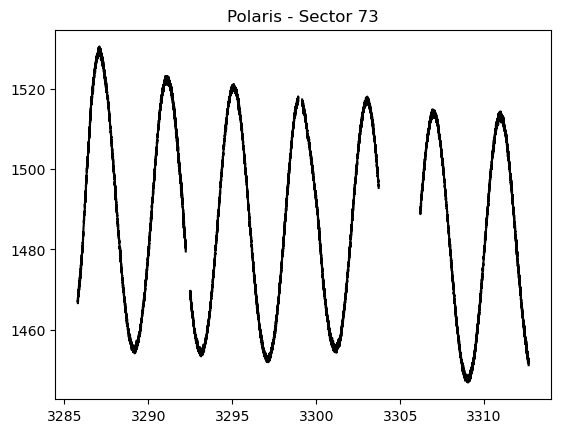

In [26]:
head_polaris = lightcurve.get_header() 

plt.plot(lightcurve.time.value, lightcurve.flux.value, color = "black")
plt.title(f"{head_polaris['NAME']} - Sector {head_polaris['Sector']}")
plt.show()

Let us visualise the weightmap of Polaris

/var/folders/5m/7k7nc4kj4xl9v9_x27814t2h0000gp/T/ipykernel_49924/3145753998.py:6: RuntimeWarning: divide by zero encountered in log10
  im = np.log10(weightmap.T*norm)


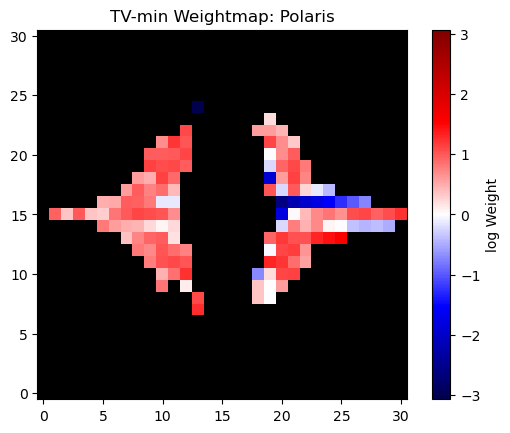

In [45]:
wm = lightcurve.hdu[2].data
plot_wmap(wm, head_polaris['NAME'])